In [252]:
!nvidia-smi

Sat May 23 16:47:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             28W /   70W |    8167MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [253]:
import pandas as pd
import pickle
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.optim.lr_scheduler as lr_sched

In [254]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [255]:
rng = np.random.default_rng(73512)

In [256]:
with open("/content/train.pkl", "rb") as f:
    raw_data = pickle.load(f)

print("Liczba próbek:", len(raw_data))

print("Przykładowa próbka:")
print(raw_data[0])

np.random.shuffle(raw_data)

Liczba próbek: 2939
Przykładowa próbka:
(array([ -1.,  -1.,  -1., ...,  78.,  40., 144.]), 0)


In [257]:
data = [x[0].astype(int) for x in raw_data]
targets = [int(x[1]) for x in raw_data]

print(pd.Series(targets).unique())
print(len(data))
print(data[0])
print(targets[0])


[0 3 1 4 2]
2939
[ 12  12  78  12  78  47  12  12  47 156  44 124  12  78  78 111  12  12
  78  12  78  47  12  12  13  41  13  93  12  88  92  92 124  77 156  30
  12  13  78  64 156 110 127  44 157  79  12  12  47  44  78  77  12  47
  12  12  78  92  92 156 156 156 125  78  92  92  28 172  60 127  28  92
  47  30  78  78  78  78  12  13  92  12  12 141  77  47  92  92  78  44
 124 124  15  12  92  92  28  78  12 141 141  28  28  12  12  12  12  28
  12  13  12  12  13  47  79  79  77 190  15  12  79 159  15  79  15  13
 190  76 159  76 190  76 190 159  76  92  92  92  76  44 157 156  44 124
  77  44  46 190  76  76 190  76 190 159  76  76 157 110  44 124  79  12
  13  92  78  92  78  77  30  76  45  28  28  79  12  12 159 190  79  12
  78  78  78  78  78  78  92  14  14  14 124 127  78 141  78  30 190  60
  60  92  76  12 188  13  76  12  12  13  76   4  79  12  79  12 110  92
  76  52  15 111  94  47  13  79 158  92 159 190 190 190  76  12  76  79
  29 125  44  13  28  28  12  28  

In [258]:
from sklearn.model_selection import train_test_split


TRAIN_SPLIT = 0.7
X_train, X_val, y_train, y_val = train_test_split(
    data,
    targets,
    test_size=1 - TRAIN_SPLIT,
    stratify=targets
)

In [259]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

all_tokens = set()

for seq in X_train:
    all_tokens.update(seq)

all_tokens = sorted(list(all_tokens))

token2id = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
}

for token in all_tokens:
    token2id[token] = len(token2id)

id2token = {v: k for k, v in token2id.items()}

PAD_ID = token2id[PAD_TOKEN]
UNK_ID = token2id[UNK_TOKEN]

VOCAB_SIZE = len(token2id)

print("VOCAB_SIZE =", VOCAB_SIZE)

VOCAB_SIZE = 184


In [260]:
MAX_SEQ_LEN = 512

In [261]:
def encode_sequence(seq, max_len=MAX_SEQ_LEN):
    encoded = []

    for token in seq[:max_len]:
        encoded.append(token2id.get(token, UNK_ID))

    return torch.tensor(encoded, dtype=torch.long)

In [262]:
from torch.utils.data import Dataset

class VariableLenDataset(Dataset):
    def __init__(self, in_data, target):
        self.data = [(x, y) for x, y in zip(in_data, target)]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        in_data, target = self.data[idx]
        in_data = encode_sequence(in_data)
        return in_data, target

In [263]:
train_set = VariableLenDataset(X_train, y_train)
valid_set = VariableLenDataset(X_val, y_val)

print(len(train_set[0][0]))
print(len(train_set[1][0]))
print(train_set[0])


414
512
(tensor([  3,  15,   3,  15,  15,  80,  15,  15,  15,  15, 122, 182,  15,  15,
          3,  15,  15,  80,  15,  15,  15,  15, 122, 110,  15,  15,   3,  15,
         15,  79,  39,  62,  15,  91,  31,  15,  50,  15,  15,  15,  15,  15,
        123,  31,  31,  31,  15,   3,   3,  15, 117, 117,  15,   3,   3,  94,
        117, 117,  94,   4,  92,  92,  14,  92,  92,  14, 110,  15,  23,  47,
         35,  48, 182, 122,  42,  15, 153,  47,  15, 122,  18,  15,  18,  18,
         47,  15,  15,  48,  18,  15,  18,  18, 118,  18,  47, 108,  15,  48,
         18,  15, 155,  31,  31,  31,  31,  31,  31,  31,  15,   8, 142,  48,
        122,  29,  15, 122,  18,  42, 122, 118,  15, 122,  15, 110,  15, 155,
         48, 182,  15, 110,  15,  18,  48, 122, 110, 182, 122, 110, 122, 122,
         42, 122, 122, 110, 110, 110, 118,   5,   4, 137,  94,  94,  15,  15,
        161,  62,  18,  94,  62,  32,  53,  83,  17,  63,  17,  17,  63,  17,
         17,  30,  30,  47,  18, 182, 122,  38, 117, 12

In [264]:
num_classes = 5

class_counts = torch.bincount(torch.tensor(y_train), minlength=num_classes)

class_weights = 1.0 / class_counts.float()

# normalizacja opcjonalna
class_weights = class_weights / class_weights.sum() * num_classes

print(class_weights)

tensor([0.1954, 0.6675, 2.0644, 0.7215, 1.3512])


In [265]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

def pad_collate(batch, pad_value=PAD_ID):
    xx, yy = zip(*batch)
    x_lens = [len(x) for x in xx]

    xx_pad = pad_sequence(xx, batch_first=True, padding_value=pad_value)

    yy = torch.tensor(yy, dtype=torch.long)

    return xx_pad, yy, x_lens

In [266]:
BATCH_SIZE = 32
HIDDEN_SIZE = 128
EMBEDDING_SIZE = 64
OUT_SIZE = 5
NUM_LAYERS = 4
BIDIRECTIONAL = True
DROPOUT = 0.5
LR = 1e-4
TRAIN_EPOCHS = 100
CLIP_GRAD = False
SCHEDULER = lr_sched.CosineAnnealingLR
SCHEDULER_T_MAX = TRAIN_EPOCHS
LR_ETA_MIN = 1e-5
LAMBDA_REG = 3e-2
OPTIMIZER = torch.optim.AdamW
LOSS_MODULE = nn.CrossEntropyLoss

In [267]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size, num_layers, out_size, padding_idx=PAD_ID, bidirectional = False):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        if bidirectional:
            self.bidirectional = 2
        else:
            self.bidirectional = 1
        self.embedding = nn.Embedding(vocab_size, emb_size, padding_idx=padding_idx)
        self.lstm = nn.LSTM(input_size = emb_size, hidden_size = hidden_size, num_layers = num_layers, bidirectional=bidirectional, dropout=DROPOUT, batch_first=True)
        self.fc = nn.Linear(hidden_size*self.bidirectional, out_size)

    def init_hidden(self, batch_size):
        hidden = torch.zeros(self.num_layers*self.bidirectional , batch_size, self.hidden_size)
        state = torch.zeros(self.num_layers*self.bidirectional , batch_size, self.hidden_size)
        return hidden, state

    def forward(self, x, x_len, hidden=None):
        x = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(x, x_len, batch_first=True, enforce_sorted=False)
        # if hidden is None:
        #     packed_out, (hn, cn) = self.lstm(packed)
        # else:
        packed_out, (hn, cn) = self.lstm(packed, hidden)
        if self.bidirectional == 1:
            out = hn[-1]
        else:
            forward_last = hn[-2]
            backward_last = hn[-1]
            out = torch.cat((forward_last, backward_last), dim=1)

        return self.fc(out), (hn, cn)

In [268]:
model = LSTMClassifier(VOCAB_SIZE, EMBEDDING_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUT_SIZE, padding_idx=PAD_ID, bidirectional=BIDIRECTIONAL).to(device)
optimizer = OPTIMIZER(model.parameters(), lr = LR, weight_decay=LAMBDA_REG)
loss_fun = LOSS_MODULE(weight=class_weights).to(device)
scheduler = SCHEDULER(
    optimizer,
    T_max=SCHEDULER_T_MAX,  # długość "cyklu"
    eta_min=LR_ETA_MIN         # minimalny learning rate
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params}")

model


Trainable parameters: 1397509


LSTMClassifier(
  (embedding): Embedding(184, 64, padding_idx=0)
  (lstm): LSTM(64, 128, num_layers=4, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=256, out_features=5, bias=True)
)

In [269]:
def evaluate_model(model, dataset, loss_module):
    loader = DataLoader(
        dataset, batch_size=1000, shuffle=False, num_workers=2, pin_memory=True, drop_last=False, collate_fn=pad_collate
    )
    model.eval()
    loss = 0
    n_samples = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, target, x_len in loader:
            x = x.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            hidden, state = model.init_hidden(x.shape[0])
            hidden, state = hidden.to(device, non_blocking=True), state.to(device, non_blocking=True)
            pred, _ = model(x, x_len, (hidden, state))
            loss += loss_module(pred, target).item() * x.size(0)  # sum loss over batch
            n_samples += x.size(0)

            all_preds.append(pred.cpu())
            all_targets.append(target.cpu())

    loss = loss / n_samples if n_samples > 0 else 0

    acc = (torch.argmax(torch.cat(all_preds),1).cpu()==torch.cat(all_targets)).sum().item()/len(torch.cat(all_targets))
    return loss, acc, all_preds

In [270]:
import copy
import datetime
import matplotlib.pyplot as plt

def train_model(
    model,
    train_dataset,
    valid_dataset,
    batch_size,
    hidden_size,
    embedding_size,
    num_layers,
    bidirectional,
    dropout,
    num_epochs,
    loss_module,
    optimizer,
    scheduler,
    lr,
    eta_min,
    lambda_reg,
    verbose=0,
    print_loss_n_times=20,
):
    def print_and_log(*args):
        txt = " ".join(str(arg) for arg in args)
        print(txt)
        with open("trainingresults.log", "a") as f:
            f.write(txt + "\n")

    with open("trainingresults.log", "a") as f:
        f.write(
            "\n\n" + "------------------------------------------------------" + "\n"
        )
    timestamp = datetime.datetime.now().strftime("%H:%M:%S %d.%m.%Y")
    print_and_log(f"TIMESTAMP: {timestamp}")
    print_and_log("--- TRAINING FOR PARAMS ---")
    # print_and_log(
    #     f"model architecture:",
    #     [len(p) for idx, p in enumerate(model.parameters()) if idx % 2 == 0],
    # )
    print_and_log(f"{batch_size=}")
    print_and_log(f"{hidden_size=}")
    print_and_log(f"{embedding_size=}")
    print_and_log(f"{num_layers=}")
    print_and_log(f"{bidirectional=}")
    print_and_log(f"{dropout=}")
    print_and_log(f"{num_epochs=}")
    print_and_log(f"{lr=}")
    print_and_log(f"{eta_min=}")
    print_and_log(f"{lambda_reg=}")
    print_and_log("-----------")

    trainloader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, collate_fn=pad_collate
    )


    train_losses = []
    valid_losses = []
    valid_accuracies = []

    best_val_loss = float("inf")
    best_model_state = None
    # data_time=0
    # compute_time=0

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        n_samples = 0
        for x, targets, x_len in trainloader:
            x = x.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            hidden, state = model.init_hidden(x.size(0))
            hidden, state = hidden.to(device, non_blocking=True), state.to(device, non_blocking=True)
            preds, _ = model(x, x_len, (hidden,state))
            # preds, _ = model(x, x_len)
            loss = loss_module(preds, targets)
            epoch_loss += loss.item()
            loss.backward()
            if CLIP_GRAD:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()

            # data_time += (t1 - t0)
            # compute_time += (t2 - t1)
            epoch_loss += loss.item() * x.size(0)
            n_samples += x.size(0)

        scheduler.step()
        train_loss = epoch_loss / n_samples
        # print(f"Epoch {epoch+1}/{num_epochs} | train_loss={train_loss:.4f}")
        train_losses.append(train_loss)
        val_loss, val_acc, _ = evaluate_model(model, valid_dataset, loss_module)
        valid_losses.append(val_loss)
        valid_accuracies.append(val_acc)
        # print(f"Epoch {epoch+1}/{num_epochs} | val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

        if verbose and (epoch + 1) % max(1, num_epochs // print_loss_n_times) == 0:
            # print("data loading time:", data_time)
            # print("compute time:", compute_time)
            # print("CPU %:", psutil.cpu_percent())
            # print(subprocess.getoutput("nvidia-smi"))
            print_and_log(
                f"Epoch {(epoch+1):02d}/{num_epochs} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f}"
            )

    # wczytanie najlepszego modelu
    model.load_state_dict(best_model_state)

    plt.figure(figsize=(8, 5))
    plt.plot(train_losses[0:], label="train") # possible cut for first epochs
    plt.plot(valid_losses[0:], label="valid")
    plt.legend()
    plt.title("Final training history")
    plt.show()

    return model, train_losses, valid_losses

TIMESTAMP: 16:47:47 23.05.2026
--- TRAINING FOR PARAMS ---
batch_size=32
hidden_size=128
embedding_size=64
num_layers=4
bidirectional=True
dropout=0.5
num_epochs=100
lr=0.0001
eta_min=1e-05
lambda_reg=0.03
-----------
Epoch 05/100 | train_loss=0.9931 | val_loss=1.0271 | val_acc=0.6542
Epoch 10/100 | train_loss=0.5604 | val_loss=0.7197 | val_acc=0.7302
Epoch 15/100 | train_loss=0.4076 | val_loss=0.6432 | val_acc=0.7982
Epoch 20/100 | train_loss=0.2539 | val_loss=0.6817 | val_acc=0.8560
Epoch 25/100 | train_loss=0.3344 | val_loss=0.6468 | val_acc=0.8299
Epoch 30/100 | train_loss=0.2463 | val_loss=0.6456 | val_acc=0.8379
Epoch 35/100 | train_loss=0.1193 | val_loss=0.6412 | val_acc=0.8787
Epoch 40/100 | train_loss=0.0896 | val_loss=0.5604 | val_acc=0.8866
Epoch 45/100 | train_loss=0.0737 | val_loss=0.6236 | val_acc=0.8878
Epoch 50/100 | train_loss=0.0681 | val_loss=0.6481 | val_acc=0.8923
Epoch 55/100 | train_loss=0.0493 | val_loss=0.6435 | val_acc=0.8923
Epoch 60/100 | train_loss=0.0402 |

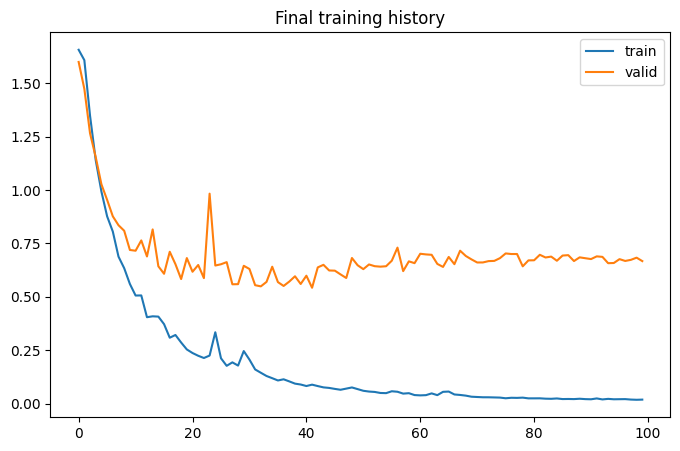

Best validation loss: 0.5427
Best validation accuracy: 0.8844


In [271]:
model, train_losses, valid_losses = train_model(
    model,
    train_set,
    valid_set,
    batch_size=BATCH_SIZE,
    num_epochs=TRAIN_EPOCHS,
    hidden_size=HIDDEN_SIZE,
    embedding_size=EMBEDDING_SIZE,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    dropout=DROPOUT,
    loss_module=loss_fun,
    optimizer=optimizer,
    scheduler=scheduler,
    lr=LR,
    eta_min=LR_ETA_MIN,
    lambda_reg=LAMBDA_REG,
    verbose=1,
    print_loss_n_times=20
)

best_val_results = evaluate_model(model, valid_set, loss_fun)
print(f"Best validation loss: {best_val_results[0]:.4f}")
print(f"Best validation accuracy: {best_val_results[1]:.4f}")

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
with open(f"model_state_{timestamp}.pkl", "wb") as f:
    torch.save(model.state_dict(), f)

### Sprawdzenie walidaycjnych predykcji

In [272]:
preds = best_val_results[2]
print(torch.argmax(torch.cat(preds),1).cpu())

tensor([0, 4, 3, 0, 3, 1, 0, 1, 0, 2, 3, 0, 3, 1, 0, 3, 3, 0, 0, 1, 0, 0, 0, 2,
        1, 0, 0, 3, 3, 3, 1, 0, 2, 4, 2, 3, 2, 3, 3, 3, 4, 1, 0, 0, 1, 0, 4, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 3, 2, 0, 1, 3, 0, 2, 2, 0, 1, 1, 4,
        1, 2, 3, 2, 0, 0, 2, 0, 4, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 2,
        1, 1, 1, 0, 0, 3, 0, 0, 0, 0, 1, 3, 0, 0, 2, 0, 0, 2, 0, 0, 0, 3, 0, 2,
        2, 0, 2, 3, 1, 0, 1, 3, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 3, 4, 0, 0, 0, 0,
        0, 1, 0, 4, 4, 0, 4, 0, 0, 2, 0, 0, 4, 3, 0, 1, 1, 2, 0, 3, 1, 1, 0, 1,
        0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 3, 0, 0, 0, 2, 0, 0, 4, 1, 0, 0, 3, 2, 1,
        0, 3, 4, 0, 4, 0, 0, 0, 1, 1, 2, 3, 0, 4, 4, 0, 0, 0, 2, 0, 0, 0, 0, 0,
        1, 0, 0, 3, 3, 0, 0, 0, 2, 3, 4, 0, 0, 3, 1, 0, 0, 0, 3, 1, 0, 1, 0, 0,
        0, 1, 0, 3, 0, 0, 3, 0, 0, 1, 3, 0, 3, 0, 0, 0, 1, 1, 0, 3, 0, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 0, 4, 0, 0, 0, 2, 0, 0, 3, 0, 0, 0, 3, 3, 0, 0, 0, 4,
        0, 3, 0, 0, 3, 0, 0, 1, 1, 0, 1,

In [273]:
print((torch.argmax(torch.cat(preds),1).cpu() == 0).sum())
print((torch.argmax(torch.cat(preds),1).cpu() != 0).sum())

tensor(467)
tensor(415)


## GENEROWANIE PREDYKCJI

In [274]:
LOAD_SAVED_MODEL = False
if LOAD_SAVED_MODEL:
    # dokładnie ta sama architektura
    model = LSTMClassifier(VOCAB_SIZE, EMBEDDING_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUT_SIZE, padding_idx=PAD_ID, bidirectional=BIDIRECTIONAL)
    model.load_state_dict(torch.load(f"/content/INSERT_FILE_NAME_HERE.pkl", map_location=device))
    model.eval()
    model = model.to(device)

    print("Check loaded model accuracy")
    best_val_results = evaluate_model(model, valid_set, loss_fun)
    print(f"Best validation loss: {best_val_results[0]:.4f}")
    print(f"Best validation balanced accuracy: {best_val_results[1]:.4f}")

else:
    model.eval()
    model = model.to(device)

with open("test_no_target.pkl", "rb") as f:
    test_data = pickle.load(f)

print("Liczba próbek:", len(test_data))
test_data= [x.astype(int) for x in test_data]
# print('losowa próbka:', test_data[0])


test_set = VariableLenDataset(test_data, torch.tensor([0]*len(test_data)))  # dummy targets
# print(len(test_set[0][0]))
# print(len(test_set[1][0]))
# print(test_set[0])

test_loader = DataLoader(test_set, batch_size=1000, shuffle=False, num_workers=2, pin_memory=True, drop_last=False, collate_fn=pad_collate)

predictions = []
with torch.no_grad():
    for x, _, x_len in test_loader:
        x = x.to(device, non_blocking=True)
        hidden, state = model.init_hidden(x.size(0))
        hidden, state = hidden.to(device, non_blocking=True), state.to(device, non_blocking=True)
        pred, _ = model(x, x_len, (hidden, state))
        predictions.append(pred.cpu())

predictions = torch.argmax(torch.cat(predictions),1).cpu()
df = pd.DataFrame({
    0: predictions
})

df.to_csv("pred.csv", index=False, header=False)
print("\nPredictions saved")

assert len(df) == len(test_data), "Liczba predykcji != liczba utworów"
assert df.shape[1] == 1, "Zła liczba kolumn"
assert df[0].between(0, 4).all(), "Klasy poza zakresem 0-4"


Liczba próbek: 1103

Predictions saved
